In [1]:
import numpy as np 
import scipy.optimize as opt
import scipy as sc
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [2]:
n_demands = 2

# holding_cost = 1
# backorder_cost = 3

n_features = 10

In [3]:
H = np.array([1, 1])
B = np.array([8, 8])
C = [
    [0, 2],
    [2, 0]
]

In [4]:
n_data = 1000

# features data 
import torch.nn.functional as F

data_model = nn.Sequential(
  nn.Linear(n_features, 2),
  nn.ReLU(),
)

def make_data(n_data):
    X2 = 2 * torch.randn(n_data, n_features) + 0.1
    X1 = torch.randn(n_data, n_features) - 0.2
    mu = torch.rand(n_data)
    mu = mu.view(-1,1).repeat(1,n_features)
    X = (X1 + X2 * mu)
    
    y = data_model(X) 
    y = 0.1 + F.relu(y + 0.1 * torch.randn(y.shape))
    return y, X

Y, X_train = make_data(n_data)
Y_test, X_test = make_data(10000)

# tt1 = problem.solve(probs, all_ = False) 
# test_tt1 = problem.solve(test_probs, all_ = False)

In [5]:
# torch.save(X_train, "trainX.npy")
# torch.save(Y, "trainY.npy")
# torch.save(X_test, "testX.npy")
# torch.save(Y_test, "testY.npy")

In [6]:
# n_data = 1000

# # features data 
# import torch.nn.functional as F

# data_model = nn.Sequential(
#   nn.Linear(n_features, 2),
#   nn.ReLU(),
# )

# def make_data(n_data):
#     X = torch.randn(n_data, n_features) 
#     y = data_model(X) + 0.1
#     return y * (1 + torch.randn(y.shape) * 0.), X

# Y, X_train = make_data(n_data)
# Y_test, X_test = make_data(10000)

# # tt1 = problem.solve(probs, all_ = False) 
# # test_tt1 = problem.solve(test_probs, all_ = False)

In [7]:
def loss(q, d, H, B, C): 
    a00 = torch.minimum(q[:,0], d[:,0])
    a11 = torch.minimum(q[:,1], d[:,1])
    a01 = torch.minimum(q[:,0] - a00, d[:,1] - a11)
    a10 = torch.minimum(q[:,1] - a11, d[:,0] - a00)
    
    v1 = torch.sum(H[0] * F.relu(q[:,0] - (a00 + a01)) + H[1] * F.relu(q[:,1] - (a11 + a10)))
    
    v2 = torch.sum(B[0] * F.relu(d[:,0] - (a00 + a10)) + B[1] * F.relu(d[:,1] - (a11 + a01)))
    
    v3 = torch.sum(C[0][0] * a00 + C[0][1] * a01 + C[1][0] * a10 + C[1][1] * a11) 

    return v1 + v2 + v3

In [65]:
def loss_robust(q, d, H, B, C, Gamma = 0): 
    a00 = torch.minimum(q[:,0], d[:,0])
    a11 = torch.minimum(q[:,1], d[:,1])
    a01 = torch.minimum(q[:,0] - a00, d[:,1] - a11)
    a10 = torch.minimum(q[:,1] - a11, d[:,0] - a00)
    
    v1 = torch.sum(H[0] * F.relu(q[:,0] - (a00 + a01)) + H[1] * F.relu(q[:,1] - (a11 + a10)))
    
    v2 = torch.sum(B[0] * F.relu(d[:,0] - (a00 + a10)) + B[1] * F.relu(d[:,1] - (a11 + a01)))
    
    v3 = torch.sum(C[0][0] * a00 + C[0][1] * a01 + C[1][0] * a10 + C[1][1] * a11) 

    robust = torch.sqrt(torch.sum(torch.square(F.relu(q[:,0] - (a00 + a01))) + 
                                   torch.square(F.relu(d[:,0] - (a00 + a10))) +
                                   torch.square(F.relu(q[:,1] - (a11 + a10))) +
                                   torch.square(F.relu(d[:,1] - (a11 + a01))) ))
    # robust = torch.sqrt(torch.square(v1) + torch.square(v2))
    
    # robust = torch.sqrt(
    #     torch.sum(torch.square(a00)) + 
    #     torch.sum(torch.square(a01)) + 
    #     torch.sum(torch.square(a10)) + 
    #     torch.sum(torch.square(a11)) 
    # )
    # robust = torch.sqrt(
    #             torch.square(torch.sum(a00)) + 
    #             torch.square(torch.sum(a01)) + 
    #             torch.square(torch.sum(a10)) + 
    #             torch.square(torch.sum(a01))
    # )
    
    # print(v1 + v2 + v3, Gamma * robust)
    return v1 + v2 + v3 + Gamma * robust

In [9]:
def eval_forecast_model(X_train, model, D):    
    q = model(X_train) #+ torch.mean(Y)
    return loss(q, D, H, B, C) 

In [10]:
class Forecast(nn.Module):
    def __init__(self, n_features, n_demands):
        super(Forecast, self).__init__()
    
        self.forecast = nn.Linear(n_features, 2)
        # self.linear = nn.Linear(n_features, 100)
        # self.forecast = nn.Linear(100, 2)

    def forward(self, x): 
        # f = F.relu(self.linear(x))
        # return F.relu(self.forecast(f)) 
        
        f = F.relu(self.forecast(x))
        return F.relu(f + 0.1) 
#         return newsvendor.get_cost_from_prob(f)

In [11]:
YY = Y #- torch.mean(Y)

two_stage_forecast = Forecast(n_features, 2)

criterion = nn.MSELoss()
optimizer_twostage = optim.Adam(two_stage_forecast.parameters(), lr=0.0001)

all_errs = []
mses = []
batch_size = 10
for epoch in range(500):  # loop over the dataset multiple times
    for i in range(0, YY.size()[0], batch_size):
        c = torch.tensor(YY[i:i+batch_size:]).float()
        input = torch.tensor(X_train[i:i+batch_size,:]).float()

        optimizer_twostage.zero_grad()

        f = two_stage_forecast(input)
        
        # print(f)
        # print(c)
        mse = criterion(f, c) 

        mse.backward()
        optimizer_twostage.step()
        
        mses = np.append(mses, mse.detach().numpy())
#     if epoch % 50 == : 
#         errs_two_stage = eval_forecast_model(X_test, two_stage_forecast, test_targets)
#         all_errs.append(np.mean(errs_two_stage))
#         print("Error: ", np.mean(errs_two_stage))
    print("MSE: ", np.mean(mses))
    test_errs = eval_forecast_model(X_test, two_stage_forecast, Y_test)
    train_errs = eval_forecast_model(X_train, two_stage_forecast, Y)
    print("true error: ", test_errs.item(), train_errs.item())

MSE:  0.5791237436234951
true error:  37747.36328125 3930.74267578125
MSE:  0.5698689221590757
true error:  37743.1875 3927.547119140625
MSE:  0.5609189391632875
true error:  37697.328125 3920.0263671875
MSE:  0.5521276080980897
true error:  37609.13671875 3907.314697265625
MSE:  0.5434663728773594
true error:  37493.07421875 3891.475830078125
MSE:  0.534956341261665
true error:  37352.5859375 3874.5400390625
MSE:  0.5266138958505222
true error:  37186.421875 3856.03857421875
MSE:  0.5184464975260198
true error:  36990.57421875 3834.6044921875
MSE:  0.5103733877506521
true error:  36763.5703125 3809.573486328125
MSE:  0.5023826071918011
true error:  36492.03515625 3779.925537109375
MSE:  0.4944210668450052
true error:  36174.37109375 3745.216064453125
MSE:  0.48646822179357213
true error:  35824.0859375 3706.824462890625
MSE:  0.4785327721788333
true error:  35448.26171875 3665.019775390625
MSE:  0.470620927230588
true error:  35034.47265625 3616.407470703125
MSE:  0.46270674280822277


In [12]:
errs_two_stage = eval_forecast_model(X_test, two_stage_forecast, Y_test)
train_errs_two_stage = eval_forecast_model(X_train, two_stage_forecast, Y)

In [13]:
print("2-Stage Test error")
print(errs_two_stage.item() / len(Y_test))

2-Stage Test error
0.5685798828125


In [14]:
print("2-Stage Train error")
print(train_errs_two_stage.item() / len(Y))

2-Stage Train error
0.5597637939453125


In [59]:
def train_with_loss(XX, YY, loss_func, verbose = True):
    forecast = Forecast(n_features, 2)

    best_error = 100000
    optimizer_task = optim.Adam(forecast.parameters(), lr=0.0001)

    all_errs = []
    all_test_errs = []
    batch_size = 50
    for epoch in range(5000):  # loop over the dataset multiple times
        for i in range(0, YY.size()[0], batch_size):
            d = torch.tensor(YY[i:i+batch_size:]).float()
            input = torch.tensor(XX[i:i+batch_size,:]).float()

            optimizer_twostage.zero_grad()

            f = forecast(input)

            error = loss_func(f, d, H, B, C) / len(d)

            error.backward()
            optimizer_task.step()

            all_errs.append(error.detach().numpy())
    #     if epoch % 50 == : 
    #         errs_two_stage = eval_forecast_model(X_test, two_stage_forecast, test_targets)
    #         all_errs.append(np.mean(errs_two_stage))
    #         print("Error: ", np.mean(errs_two_stage))
        if verbose:
            print("epoch:", epoch)
            print("Cost: ", np.mean(all_errs))
            test_errs = eval_forecast_model(X_test, forecast, Y_test)
            train_errs = eval_forecast_model(X_train, forecast, Y)
            print("true cost: ", test_errs.item(), train_errs.item())
            all_test_errs.append(test_errs.item())

            if test_errs < best_error: 
                best_error = test_errs
    #             torch.save(forecast.state_dict(), 'best-model-parameters.pt') # official recommended
    # forecast.load_state_dict(torch.load('./best-model-parameters.pt'))
    return forecast, all_test_errs

In [64]:
task_forecast, all_task_errors = train_with_loss(X_train, Y, loss)

epoch: 0
Cost:  4.113075
true cost:  40705.94921875 4102.67626953125
epoch: 1
Cost:  4.1030025
true cost:  40474.5 4080.337158203125
epoch: 2
Cost:  4.0916667
true cost:  40213.453125 4055.074951171875
epoch: 3
Cost:  4.079425
true cost:  39938.1640625 4027.65283203125
epoch: 4
Cost:  4.0664053
true cost:  39656.50390625 3998.57763671875
epoch: 5
Cost:  4.052801
true cost:  39368.47265625 3968.20654296875
epoch: 6
Cost:  4.0387354
true cost:  39079.5 3937.1005859375
epoch: 7
Cost:  4.024329
true cost:  38790.16015625 3905.885986328125
epoch: 8
Cost:  4.0096364
true cost:  38500.7265625 3874.24267578125
epoch: 9
Cost:  3.994738
true cost:  38212.66015625 3842.521728515625
epoch: 10
Cost:  3.9796393
true cost:  37928.50390625 3810.00927734375
epoch: 11
Cost:  3.9643235
true cost:  37646.66015625 3777.45361328125
epoch: 12
Cost:  3.9488564
true cost:  37366.01953125 3745.472900390625
epoch: 13
Cost:  3.9333243
true cost:  37088.26953125 3713.827880859375
epoch: 14
Cost:  3.9178035
true co

In [17]:
print(np.min(all_task_errors))

3205.35986328125


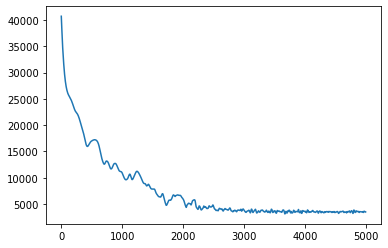

In [66]:
plt.plot(range(len(all_task_errors)), all_task_errors)

In [19]:
test_cost_task = eval_forecast_model(X_test, task_forecast, Y_test)
train_cost_task = eval_forecast_model(X_train, task_forecast, Y)

In [20]:
print("Task-based forecast Test cost")
print(test_cost_task.item() / len(Y_test))

Task-based forecast Test cost
0.34595947265625


In [21]:
print("Task-based forecast Train cost")
print(train_cost_task.item() / len(Y))

Task-based forecast Train cost
0.32689447021484375


In [22]:
task_forecast(X_test)

tensor([[1.9359, 0.1000],
        [1.1400, 0.1000],
        [0.1000, 1.2774],
        ...,
        [0.1000, 1.9492],
        [1.1610, 0.2981],
        [0.1000, 0.6946]], grad_fn=<ReluBackward0>)

In [101]:
def get_robust_func(gamma):
    return lambda q, d, H, B, C : loss_robust(q, d, H, B, C, Gamma = gamma)

loss_robust_ = get_robust_func(2)

robust_forecast, all_robust_errors = train_with_loss(X_train, Y, loss_robust_)

epoch: 0
Cost:  3.5661144
true cost:  34598.8203125 3304.92529296875
epoch: 1
Cost:  3.5552344
true cost:  34389.16796875 3281.94482421875
epoch: 2
Cost:  3.5429916
true cost:  34154.51953125 3256.140625
epoch: 3
Cost:  3.5299244
true cost:  33902.5703125 3229.392578125
epoch: 4
Cost:  3.516422
true cost:  33640.9140625 3202.021484375
epoch: 5
Cost:  3.5026865
true cost:  33377.09375 3174.814208984375
epoch: 6
Cost:  3.4887736
true cost:  33111.54296875 3147.175537109375
epoch: 7
Cost:  3.4747665
true cost:  32845.89453125 3120.17578125
epoch: 8
Cost:  3.460749
true cost:  32581.0859375 3093.25830078125
epoch: 9
Cost:  3.4467072
true cost:  32315.4140625 3066.3486328125
epoch: 10
Cost:  3.432667
true cost:  32047.212890625 3039.086181640625
epoch: 11
Cost:  3.4186018
true cost:  31780.71484375 3011.72119140625
epoch: 12
Cost:  3.4045212
true cost:  31515.486328125 2984.705078125
epoch: 13
Cost:  3.3904593
true cost:  31252.220703125 2958.9091796875
epoch: 14
Cost:  3.3765125
true cost:

Text(0, 0.5, 'test cost')

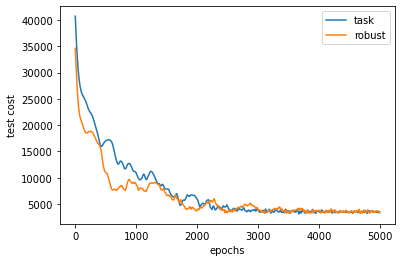

In [102]:
plt.plot(range(len(all_task_errors)), all_task_errors, label = 'task')
plt.plot(range(len(all_robust_errors)), all_robust_errors, label = 'robust')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('test cost')

In [53]:
test_cost_task_robust = eval_forecast_model(X_test, robust_forecast, Y_test)
train_cost_task_robust = eval_forecast_model(X_train, robust_forecast, Y)

In [26]:
print("Task-based robust forecast Test cost")
print(test_cost_task_robust.item() / len(Y_test))

Task-based robust forecast Test cost
2.38775234375


In [27]:
print("Task-based forecast Train cost")
print(train_cost_task_robust.item() / len(Y))

Task-based forecast Train cost
2.220210205078125


In [28]:
H

array([1, 1])

In [35]:
def noise_eval_forecast_model(X, model, D, h, b):
    q = model(X) #+ torch.mean(Y)
    all_costs = []
    for i in range(len(h)): 
        H_ = torch.maximum(h[i], 0.1 * torch.ones_like(h[i])) 
        B_ = torch.maximum(b[i], 0.1 * torch.ones_like(h[i])) 
        # print(H_)
        # cur = loss(q[i,:].unsqueeze(0), D[i,:].unsqueeze(0), H_, B_, C)
        cur = loss(q, D, H_, B_, C) / len(q)
        all_costs.append(cur.item())
    return all_costs

def get_noise_eval(X, Y, noise):
    h = [] 
    b = []
    for i in range(1000):
        h.append(np.maximum(0, H + (np.random.rand(2) - 0.5) * noise))
        b.append(np.maximum(0, B + (np.random.rand(2) - 0.5) * noise))
    h = torch.tensor(np.array(h))
    b = torch.tensor(np.array(b))
    two_stage_noise =  noise_eval_forecast_model(X, two_stage_forecast, Y, h, b)
    task_noise =  noise_eval_forecast_model(X, task_forecast, Y, h, b)
    robust_task_noise =  noise_eval_forecast_model(X, robust_forecast, Y, h, b)
    return np.array(two_stage_noise), np.array(task_noise), np.array(robust_task_noise)

In [36]:
def get_quantiles(quantiles, vals):
    all_ = []
    for quantile in quantiles:
        a = np.quantile(vals, quantile)
        all_.append(a)
    return np.array(all_)

In [86]:
for noise in [5]:
    two_stage_noise, task_noise, robust_task_noise = get_noise_eval(X_test, Y_test, noise)


(array([ 14.,  38., 114., 139., 187., 188., 149.,  96.,  53.,  22.]),
 array([0.38643867, 0.4242143 , 0.46198993, 0.49976556, 0.53754119,
        0.57531682, 0.61309245, 0.65086808, 0.68864371, 0.72641934,
        0.76419497]),
 <BarContainer object of 10 artists>)

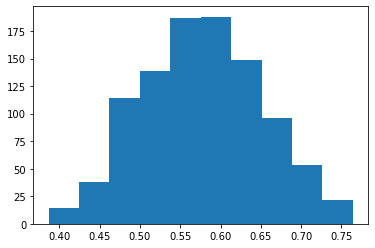

In [87]:
plt.hist(two_stage_noise)

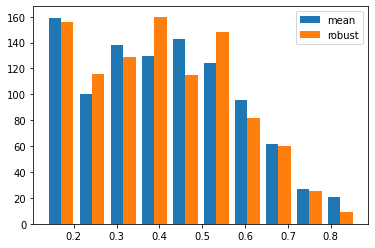

In [88]:
plt.hist([task_noise, robust_task_noise], label = ['mean', 'robust'])
plt.legend()

(array([182., 114., 131., 145., 138.,  97.,  90.,  59.,  32.,  12.]),
 array([0.13132717, 0.22216418, 0.31300119, 0.4038382 , 0.49467522,
        0.58551223, 0.67634924, 0.76718625, 0.85802327, 0.94886028,
        1.03969729]),
 <BarContainer object of 10 artists>)

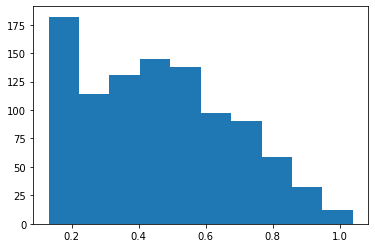

In [80]:
plt.hist(robust_task_noise)

In [73]:
def plot_quantiles(X, Y, noise_levels):
    quantiles = np.arange(0.,1,0.01)

    for noise in noise_levels:
        two_stage_noise, task_noise, robust_task_noise = get_noise_eval(X, Y, noise)


        
        two_stage_quantiles = get_quantiles(quantiles, two_stage_noise)
        task_quantiles = get_quantiles(quantiles, task_noise)
        robust_quantiles = get_quantiles(quantiles, robust_task_noise)

        ratio_two_stage = two_stage_quantiles / robust_quantiles
        ratio_task = task_quantiles / robust_quantiles
        ratio_quantiles = robust_quantiles / robust_quantiles

        plt.plot(quantiles, ratio_task, label = 'task ' + str(noise))
        plt.plot(quantiles, ratio_quantiles)
        plt.xlabel("quantile")
        plt.title('Percentage Comparison with Robust Method')
        plt.legend()

In [74]:
two_stage_noise, task_noise, robust_task_noise = get_noise_eval(X_test, Y_test, 5)

In [ ]:
np.mean(task_noise), np.mean(robust_task_noise)

(0.4596925240755081, 0.5046092339158058)

In [75]:
quantiles = np.arange(0.,1,0.01)
task_quantiles = get_quantiles(quantiles, task_noise)

In [ ]:
print(task_quantiles[0])

0.3756510317325592


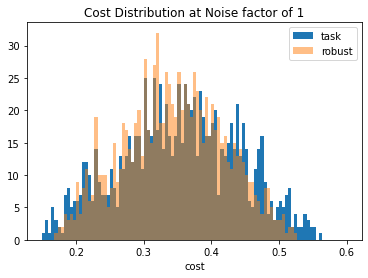

In [126]:
bins = np.linspace(0.15, 0.6, 100)
plt.hist(task_noise, bins, label = 'task')
plt.hist(robust_task_noise, bins, alpha = 0.5, label = 'robust')
plt.xlabel('cost')
plt.title("Cost Distribution at Noise factor of 1")
plt.legend()

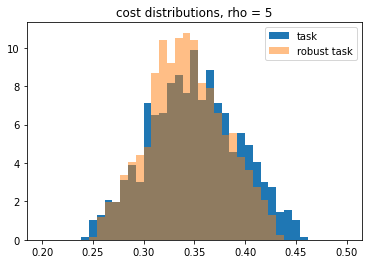

In [151]:
two_stage_noise, task_noise, robust_task_noise = get_noise_eval(X_test, Y_test, 1)
bins = np.linspace(0.2, 0.5, 40)
plt.hist(task_noise, bins, label = 'task', density = True)
plt.hist(robust_task_noise, bins, alpha = 0.5, label = 'robust task', density = True)
plt.title('cost distributions, rho = 5')
plt.legend()

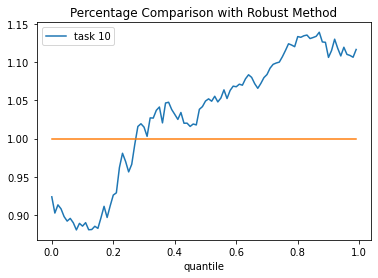

In [103]:
plot_quantiles(X_test, Y_test, [10])

In [30]:
two_stage_noise, task_noise, robust_task_noise = get_noise_eval(X_test, Y_test, 0)
two_stage_noise_test, task_noise_test, robust_task_noise_test = get_noise_eval(X_test, Y_test, 0.5)

NameError: name 'get_noise_eval' is not defined

In [ ]:
print(np.mean(two_stage_noise), np.mean(task_noise), np.mean(robust_task_noise))
print(np.mean(two_stage_noise_test), np.mean(task_noise_test), np.mean(robust_task_noise_test))

0.6053673624992371 0.4610688090324402 0.5220356583595276
0.6056296008229256 0.46125535503029824 0.5222374303042888


In [ ]:
qq = 0.95
print("no noise: ", np.quantile(two_stage_noise, qq), np.quantile(task_noise, qq), np.quantile(robust_task_noise, qq))
print("   noise: ", np.quantile(two_stage_noise_test, qq), np.quantile(task_noise_test, qq), np.quantile(robust_task_noise_test, qq))

no noise:  0.6053673624992371 0.4610688090324402 0.5220356583595276
   noise:  0.6247553348541259 0.4886940985918045 0.5487322896718979


In [ ]:
# def compare_noises(X, Y, noise, ratio = False):
#     quantiles = np.arange(0.55,1,0.01)

#     two_stage_noise_0, task_noise_0, robust_task_noise_0 = get_noise_eval(X, Y, 0)
#     two_stage_noise, task_noise, robust_task_noise = get_noise_eval(X, Y, noise)
    
#     two_stage_ratio = (two_stage_noise - two_stage_noise_0) / two_stage_noise_0
#     task_ratio = (task_noise - task_noise_0) / task_noise_0
#     robust_ratio = (robust_task_noise - robust_task_noise_0) / robust_task_noise_0

#     print(sum(task_noise < task_noise_0))

#     two_stage_quantiles_1 = get_quantiles(quantiles, two_stage_ratio)
#     task_quantiles_1 = get_quantiles(quantiles, task_ratio)
#     robust_quantiles_1 = get_quantiles(quantiles, robust_ratio)

#     if  ratio:
#         task_quantiles_1 /= robust_quantiles_1
#         robust_quantiles_1 /= robust_quantiles_1
#         plt.title('percentage increase after noise')
#     else:
#         plt.title('increase in cost after noise')
#     # plt.plot(quantiles, two_stage_quantiles_1, label = '2-stage ')
#     plt.plot(quantiles, task_quantiles_1, label = 'task ')
#     plt.plot(quantiles, robust_quantiles_1, label = 'robust')
#     plt.xlabel("quantile")
#     plt.legend()

In [31]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

In [32]:
# two-stage with distribution and saa

def generate_samples(n_samples, means, rho): 
    noises = torch.rand(n_samples, means.shape[0]) * rho
    return (torch.tensor(means) * ( 1 + noises)).detach().numpy()

def saa(demands, holding, backorder, edges): 
    K = demands.shape[0]
    N = demands.shape[1] 

    with gp.Env(empty=True) as env:
        env.setParam('OutputFlag', 0)
        env.start()
        with gp.Model(env=env) as solver:
            a_ = [(k,i,j) for k in range(K) for i in range(N) for j in range(N)]
            q_ = [i for i in range(N)]
            a = solver.addVars(a_, lb = 0, name='a')
            q = solver.addVars(q_, lb = 0, name='q')
            m = solver.addVar(lb = 0)

            for k in range(K): 
                for i in range(N): 
                    solver.addConstr(sum(a[k,i,j] for j in range(N)) <= q[i])
                    solver.addConstr(sum(a[k,j,i] for j in range(N)) <= demands[k,i])
            # for k in range(K): 
            #     solver.addConstr(holding[0] * sum(q[i] - sum(a[k,i,j] for j in range(N)) for i in range(N)) +
            #             backorder[0] * sum(demands[k,i] - sum(a[k,j,i] for j in range(N)) for i in range(N)) +
            #             sum(edges[i][j] * a[k,i,j] for i in range(N) for j in range(N))
            #             <= m)
            # solver.setObjective(m, GRB.MINIMIZE)            
            solver.setObjective(
                    sum( # K
                        holding[0] * sum(q[i] - sum(a[k,i,j] for j in range(N)) for i in range(N)) +
                        backorder[0] * sum(demands[k,i] - sum(a[k,j,i] for j in range(N)) for i in range(N)) +
                        sum(edges[i][j] * a[k,i,j] for i in range(N) for j in range(N))
                        for k in range(K)) 
                    , GRB.MINIMIZE)
                
            solver.optimize()
            qq = []
            for v in solver.getVars():
                # print(v.VarName)
                if 'q' in v.VarName:
                    qq.append(v.X)
                # if 'a' in v.VarName: 
                #     print(v.VarName, v.X)
            return torch.tensor(qq).unsqueeze(0), solver.getObjective().getValue()

In [44]:
saa_rho = 0.1
saa_n_samples = 200
all_costs = [] 
all_decisions = []
for x,d in zip(X_test, Y_test): 
    pred = two_stage_forecast(x)
    samples = generate_samples(saa_n_samples, pred, saa_rho)
    # print('the demands', samples, pred)
    decision, obj = saa(samples, H, B, C)
    cost = loss(decision, d.unsqueeze(0), H, B, C)
    # print('prediction', pred)
    # print(obj, cost)
    all_costs.append(cost.item())
    print(np.mean(all_costs))
    all_decisions.append(decision[0].numpy())
all_decisions = np.array(all_decisions)
all_decisions = torch.tensor(all_decisions)

0.22502095997333527
0.1356450766324997
0.09586955606937408
0.1278015337884426
0.11910454034805298
0.11560352891683578
0.14377197410379136
0.15138375014066696
0.15204346179962158
0.140297794342041
0.14518923244693063
0.13691663183271885
0.12761932496841139
0.11959236061998776
0.11914017051458359
0.11826138431206346
0.11225303262472153
0.12691395771172312
0.12106085254957802
0.14776028804481028
0.16122304506245114
0.15559154545718973
0.15487994059272434
0.16840320328871408
0.16458428412675857
0.15871120817386186
0.15344902210765415
0.1722518088562148
0.19630614334139332
0.19696938196818034
0.1946840891914983
0.19010362192057073
0.22876290277098166
0.22685526245657137
0.2208145322544234
0.2167650003814035
0.214186154708669
0.21592180685777412
0.25179726362992555
0.2484465939924121
0.2494261524662739
0.24577728800830387
0.2422650908661443
0.24123682708225466
0.2363423819343249
0.23928170311062233
0.2349438446950405
0.23293805168941617
0.23488917870789158
0.24224158272147178
0.2396950802090

In [45]:
all_decisions = np.array(all_decisions)
all_decisions = torch.tensor(all_decisions)
loss(all_decisions, Y_test, H, B, C)/ len(Y_test)

tensor(0.3970, grad_fn=<DivBackward0>)

In [45]:
def noise_eval_forecast_decision(q, D, h, b):
    all_costs = []
    for i in range(len(h)): 
        H_ = torch.maximum(h[i], 0.1 * torch.ones_like(h[i])) 
        B_ = torch.maximum(b[i], 0.1 * torch.ones_like(h[i])) 
        # print(H_)
        # cur = loss(q[i,:].unsqueeze(0), D[i,:].unsqueeze(0), H_, B_, C)
        cur = loss(q, D, H_, B_, C) / len(q)
        all_costs.append(cur.item())
    return all_costs

def get_noise_eval_decision(decisions, Y, noise):
    h = [] 
    b = []
    for i in range(1000):
        h.append(H + (np.random.rand(2) - 0.5) * noise)
        b.append(B + (np.random.rand(2) - 0.5) * noise)
    h = torch.tensor(np.array(h))
    b = torch.tensor(np.array(b))
    two_stage_noise =  noise_eval_forecast_model(X, two_stage_forecast, Y, h, b)
    task_noise =  noise_eval_forecast_model(X, task_forecast, Y, h, b)
    robust_task_noise =  noise_eval_forecast_model(X, robust_forecast, Y, h, b)
    return np.array(two_stage_noise), np.array(task_noise), np.array(robust_task_noise)

In [46]:
two_stage_saa = noise_eval_forecast_model(all_decisions, X_test)

NameError: name 'noise_eval_forecast_model' is not defined

Text(0.5, 1.0, 'Cost Distribution')

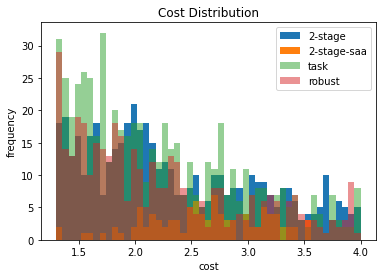

In [ ]:
# import matplotlib.pyplot as plt
# bins = np.linspace(1.3, 4, 50)
# plt.hist(two_stage_noise, bins, label = '2-stage')
# plt.hist(two_stage_saa, bins, label = '2-stage-saa')
# plt.hist(task_noise, bins, label = 'task', alpha = 0.5)
# plt.hist(rboust_task_noise, bins, label = 'robust', alpha = 0.5)
# plt.legend()
# plt.xlabel("cost")
# plt.ylabel("frequency")
# plt.title("Cost Distribution")

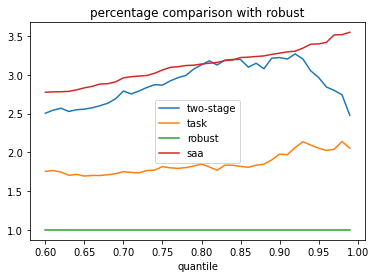

In [ ]:
# tw_ = []
# tk_ = [] 
# rb_ = []
# saa_ = []
# quantiles = np.arange(0.6,1,0.01)
# for quantile in quantiles:
#     a, b, c = np.quantile(two_stage_noise, quantile), np.quantile(task_noise, quantile), np.quantile(rboust_task_noise, quantile)
#     d = np.quantile(two_stage_saa, quantile)
#     tw_.append(a) 
#     tk_.append(b) 
#     rb_.append(c) 
#     saa_.append(d)
# tw_ = np.array(tw_)
# tk_ = np.array(tk_)
# rb_ = np.array(rb_)
# saa_ = np.array(saa_)
# tw_ /= rb_ 
# tk_ /= rb_ 
# rb_ /= rb_
# saa_ /= rb_

# plt.plot(quantiles, tw_, label = 'two-stage')
# plt.plot(quantiles, tk_, label = 'task')
# plt.plot(quantiles, rb_, label = 'robust')
# plt.plot(quantiles, saa_, label = 'saa')
# plt.xlabel("quantile")
# plt.title('percentage comparison with robust')
# plt.legend()